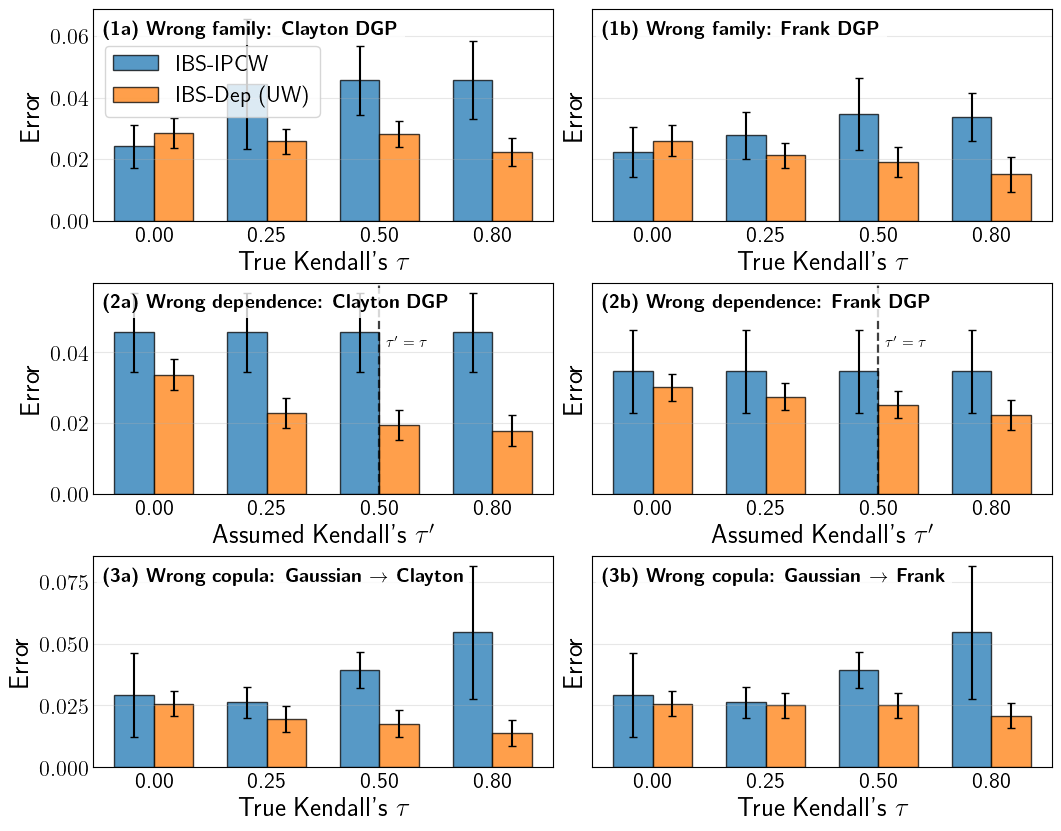

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import config as cfg

# --- Matplotlib style ---
plt.style.use("default")
plt.rcParams.update({
    "axes.labelsize": "large",
    "axes.titlesize": "large",
    "font.size": 16.0,
    "legend.fontsize": "medium",
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsfonts} \usepackage{amstext} \usepackage{bm}"
})

# --- Load data ---
filename = f"{cfg.RESULTS_DIR}/synthetic_results_wrong_copula.csv"
df = pd.read_csv(filename)

keep_exps = ["family", "dep_clayton", "dep_frank", "gaussian"]
keep_taus = np.array([0.0, 0.25, 0.5, 0.8])

dfp = df[df["experiment"].isin(keep_exps)].copy()

# Combine Clayton/Frank wrong-dependence experiments into one row.
dfp["panel"] = dfp["experiment"].replace({
    "dep_clayton": "dep",
    "dep_frank": "dep",
})

# Use assumed tau for wrong-dependence; true tau otherwise.
dfp["plot_tau"] = np.where(
    dfp["panel"].eq("dep"),
    dfp["assumed_k_tau"],
    dfp["true_k_tau"],
)

# Keep only selected tau values.
dfp = dfp[np.isclose(dfp["plot_tau"].values[:, None], keep_taus[None, :]).any(axis=1)].copy()

# Snap floating point values to exact plotting tau values.
for t in keep_taus:
    dfp.loc[np.isclose(dfp["plot_tau"], t), "plot_tau"] = float(t)

# Guard: the CSV must contain 0.25.
available = sorted(dfp["plot_tau"].unique())
missing = [float(t) for t in keep_taus if not np.any(np.isclose(available, t))]
if missing:
    raise RuntimeError(
        f"Missing tau values in CSV: {missing}. "
        "Rerun train_synthetic_wrong_copula.py with K_TAU including these values."
    )

# ---------------------------------------------------------------------
# Aggregation
# ---------------------------------------------------------------------

# Include assumed_copula so Gaussian -> Clayton and Gaussian -> Frank are kept separate.
seed_level = (
    dfp.groupby(["panel", "dgp_copula", "assumed_copula", "plot_tau", "seed"], as_index=False)
       .agg(
           err_ipcw=("err_ipcw", "mean"),
           err_dep_bguw=("err_dep_bguw", "mean"),
       )
)

agg = (
    seed_level
    .groupby(["panel", "dgp_copula", "assumed_copula", "plot_tau"], as_index=False)
    .agg(
        ipcw_mean=("err_ipcw", "mean"),
        ipcw_std=("err_ipcw", "std"),
        dep_mean=("err_dep_bguw", "mean"),
        dep_std=("err_dep_bguw", "std"),
    )
    .sort_values(["panel", "dgp_copula", "assumed_copula", "plot_tau"])
)

agg[["ipcw_std", "dep_std"]] = agg[["ipcw_std", "dep_std"]].fillna(0.0)

# ---------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------

def _yerr_from_mean_std(mean, std):
    lower = np.minimum(std, mean)
    return np.vstack([lower, std])


def plot_metric_panel(ax, sub, title, xlabel, show_legend=False, mark_true_tau=False):
    taus = keep_taus
    sub = sub.set_index("plot_tau").reindex(taus).reset_index()

    x = np.arange(len(taus))
    bar_width = 0.35

    color_ipcw = "C0"
    color_dep = "C1"

    ax.bar(
        x - bar_width / 2,
        sub["ipcw_mean"].values,
        bar_width,
        yerr=_yerr_from_mean_std(sub["ipcw_mean"].values, sub["ipcw_std"].values),
        capsize=3,
        color=color_ipcw,
        edgecolor="black",
        linewidth=1,
        alpha=0.75,
        label=r"IBS-IPCW",
    )

    ax.bar(
        x + bar_width / 2,
        sub["dep_mean"].values,
        bar_width,
        yerr=_yerr_from_mean_std(sub["dep_mean"].values, sub["dep_std"].values),
        capsize=3,
        color=color_dep,
        edgecolor="black",
        linewidth=1,
        alpha=0.75,
        label=r"IBS-Dep",
    )

    if mark_true_tau:
        true_tau = 0.5
        if np.any(np.isclose(taus, true_tau)):
            true_idx = int(np.where(np.isclose(taus, true_tau))[0][0])
            ax.axvline(true_idx, color="black", linestyle="--", linewidth=1.6, alpha=0.75)
            ylim_top = ax.get_ylim()[1]
            ax.text(
                true_idx + 0.06,
                ylim_top * 0.75,
                r"$\tau'=\tau$",
                fontsize=11,
                va="top",
                ha="left",
            )

    ax.text(
        0.02, 0.95,
        title,
        transform=ax.transAxes,
        fontsize=14,
        va="top",
        ha="left",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8),
    )

    ax.set_ylabel(r"Error")
    ax.set_xlabel(xlabel)

    ax.set_xticks(x)
    ax.set_xticklabels([f"{t:.2f}" for t in taus])

    ax.tick_params(axis="y", length=0)
    ax.tick_params(axis="x", length=0)

    ax.grid(axis="y", alpha=0.3)

    if show_legend:
        ax.legend(
            frameon=True,
            loc="upper left",
            bbox_to_anchor=(0.0, 0.88),
            ncol=1,
        )


def get_sub(panel, dgp_copula, assumed_copula=None):
    sub = agg[
        (agg["panel"] == panel)
        & (agg["dgp_copula"] == dgp_copula)
    ].copy()

    if assumed_copula is not None:
        sub = sub[sub["assumed_copula"] == assumed_copula].copy()

    return sub

# ---------------------------------------------------------------------
# Plot: 3 rows x 2 columns
# ---------------------------------------------------------------------

fig, axs = plt.subplots(
    3, 2,
    figsize=(10.5, 8.2),
    constrained_layout=True,
    sharey="row",
)

# Row 1: wrong family
plot_metric_panel(
    axs[0, 0],
    get_sub("family", "clayton", assumed_copula="frank"),
    r"\textbf{(1a) Wrong family: Clayton DGP}",
    r"True Kendall's $\tau$",
    show_legend=True,
)

plot_metric_panel(
    axs[0, 1],
    get_sub("family", "frank", assumed_copula="clayton"),
    r"\textbf{(1b) Wrong family: Frank DGP}",
    r"True Kendall's $\tau$",
    show_legend=False,
)

# Row 2: wrong dependence
plot_metric_panel(
    axs[1, 0],
    get_sub("dep", "clayton", assumed_copula="clayton"),
    r"\textbf{(2a) Wrong dependence: Clayton DGP}",
    r"Assumed Kendall's $\tau'$",
    show_legend=False,
    mark_true_tau=True,
)

plot_metric_panel(
    axs[1, 1],
    get_sub("dep", "frank", assumed_copula="frank"),
    r"\textbf{(2b) Wrong dependence: Frank DGP}",
    r"Assumed Kendall's $\tau'$",
    show_legend=False,
    mark_true_tau=True,
)

# Row 3: wrong copula
plot_metric_panel(
    axs[2, 0],
    get_sub("gaussian", "gaussian", assumed_copula="clayton"),
    r"\textbf{(3a) Wrong copula: Gaussian $\rightarrow$ Clayton}",
    r"True Kendall's $\tau$",
    show_legend=False,
)

plot_metric_panel(
    axs[2, 1],
    get_sub("gaussian", "gaussian", assumed_copula="frank"),
    r"\textbf{(3b) Wrong copula: Gaussian $\rightarrow$ Frank}",
    r"True Kendall's $\tau$",
    show_legend=False,
)

plt.savefig(
    f"{cfg.PLOTS_DIR}/synthetic_wrong_copula.pdf",
    format="pdf",
    bbox_inches="tight",
)
plt.show()